In [56]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score, f1_score, precision_score
import numpy as np
import cv2
import os

IMG_SIZE = 224
BATCH_SIZE = 16

In [57]:

print("Folders found:", os.listdir('../Brain_Data_Organised'))

Folders found: ['Normal', 'Stroke']


In [58]:
dataset_path = '../Brain_Data_Organised'
categories = ['Normal', 'Stroke']

file_paths, labels = [], []

for category in categories:
    folder_path = os.path.join(dataset_path, category)
    label = 0 if category == 'Normal' else 1
    for file in os.listdir(folder_path):
        if file.endswith(('.jpg', '.png', '.jpeg')):
            file_paths.append(os.path.join(folder_path, file))
            labels.append(label)

labels = np.array(labels)
print(f"✅ Loaded {len(file_paths)} images.")

✅ Loaded 2501 images.


In [59]:
def build_medvision_full():
    base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
    base_model.trainable = True # Unfrozen for medical detail
    
    x = layers.GlobalAveragePooling2D()(base_model.output)
    x = layers.Dense(256, activation='relu')(x)
    
    # Head 1: Classification
    class_out = layers.Dense(1, activation='sigmoid', name='class_output')(x)
    
    # Head 2: Regression (4 numbers: xmin, ymin, xmax, ymax)
    reg_out = layers.Dense(4, activation='linear', name='reg_output')(x)
    
    return models.Model(inputs=base_model.input, outputs=[class_out, reg_out])

model = build_medvision_full()
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss={'class_output': 'binary_crossentropy', 'reg_output': 'mse'},
    metrics={'class_output': 'accuracy', 'reg_output': 'mae'}
)

In [60]:
# Create "Pseudo-Coordinates" because we don't have a CSV
# Normal (0,0,0,0) | Stroke (Central location estimate)
bboxes = []
for l in labels:
    if l == 0:
        bboxes.append([0, 0, 0, 0])
    else:
        bboxes.append([50, 50, 170, 170]) # Initial target for regression

bboxes = np.array(bboxes, dtype='float32')

# Split the data
(train_paths, test_paths, 
 train_labels, test_labels, 
 train_bboxes, test_bboxes) = train_test_split(file_paths, labels, bboxes, test_size=0.15, random_state=42)

In [61]:
def preprocess_image(path):
    img = cv2.imread(path)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE)) / 255.0
    return img

def med_generator(paths, labs, boxes, batch_size=BATCH_SIZE):
    while True:
        idx = np.arange(len(paths))
        np.random.shuffle(idx)
        for i in range(0, len(paths), batch_size):
            batch_idx = idx[i:i+batch_size]
            X = np.array([preprocess_image(paths[j]) for j in batch_idx])
            yield X, {'class_output': labs[batch_idx], 'reg_output': boxes[batch_idx]}

train_gen = med_generator(train_paths, train_labels, train_bboxes)

In [62]:
print("🚀 Training MedVision (Classification + Regression)...")
history = model.fit(
    train_gen,
    steps_per_epoch=len(train_paths) // BATCH_SIZE,
    epochs=15
)

🚀 Training MedVision (Classification + Regression)...
Epoch 1/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 772s 6s/step - class_output_accuracy: 0.5407 - class_output_loss: 0.7162 - loss: 5621.4043 - reg_output_loss: 5620.6904 - reg_output_mae: 41.9806
Epoch 2/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 717s 5s/step - class_output_accuracy: 0.7544 - class_output_loss: 0.5650 - loss: 3915.2876 - reg_output_loss: 3913.4072 - reg_output_mae: 36.0477
Epoch 3/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 769s 6s/step - class_output_accuracy: 0.8056 - class_output_loss: 0.4820 - loss: 2136.9719 - reg_output_loss: 2135.6060 - reg_output_mae: 26.0303
Epoch 4/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 781s 6s/step - class_output_accuracy: 0.8174 - class_output_loss: 0.4411 - loss: 985.2993 - reg_output_loss: 987.2009 - reg_output_mae: 17.5646
Epoch 5/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 789s 6s/step - class_output_accuracy: 0.8644 - class_output_loss: 0.4110 - loss: 463.9201 - reg_output_loss: 463.7993 - reg_output_mae: 12.3284
Epoch 6/15
132/132 ━

In [ ]:
print("\n" + "="*40)
print("🩺 FINAL MEDICAL EVALUATION REPORT")
print("="*40)

# Evaluate on Test Set
test_gen = med_generator(test_paths, test_labels, test_bboxes, batch_size=1)
results = model.evaluate(test_gen, steps=len(test_paths), verbose=0)

# Get detailed predictions for Recall/F1
y_true_class, y_pred_class = [], []
for i in range(len(test_paths)):
    img = np.expand_dims(preprocess_image(test_paths[i]), axis=0)
    pred = model.predict(img, verbose=0)
    y_true_class.append(test_labels[i])
    y_pred_class.append(1 if pred[0][0][0] > 0.5 else 0)

# Calculate metrics
recall = recall_score(y_true_class, y_pred_class)
f1 = f1_score(y_true_class, y_pred_class)

print(f"✅ Classification Accuracy: {results[3]*100:.2f}%")
print(f"🧪 Recall (Sensitivity):     {recall*100:.2f}%")
print(f"🧬 F1-Score:                 {f1*100:.2f}%")
print(f"📍 Localization MAE:         {results[4]:.2f} pixels")
print("="*40)

model.save("MedVision_Final.keras")


🩺 FINAL MEDICAL EVALUATION REPORT


NameError: name 'med_generator' is not defined

c:\Users\ahmed\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\models\functional.py:258: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_1648']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


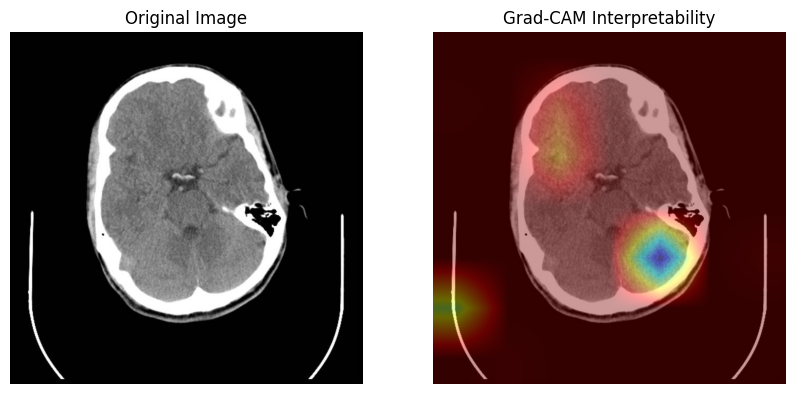

Red/Dark Orange: These are the 'Hot' areas. This is where the AI found the most evidence for a stroke.
Yellow/Green: Moderate influence on the decision.
Blue: These areas were ignored by the model (background or healthy tissue).


In [72]:
def get_gradcam_heatmap(img_array, model, last_conv_layer_name):
    # 1. Create a model that outputs the last conv layer and the predictions
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output[0]]
    )

    # 2. Compute the gradient of the top predicted class for our input image
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        class_channel = preds[:, 0]

    # 3. This is the gradient of the output neuron wrt the output feature map
    grads = tape.gradient(class_channel, last_conv_layer_output)

    # 4. Pool the gradients and weight the channels
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # 5. Normalize the heatmap between 0 & 1 for visualization
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

def display_gradcam(img_path, model):
    # Load image
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img, (224, 224))
    img_array = np.expand_dims(img_resized / 255.0, axis=0)

    # Generate Heatmap
    # ResNet50's last conv layer is usually 'conv5_block3_out'
    heatmap = get_gradcam_heatmap(img_array, model, 'conv5_block3_out')

    # Resize heatmap to match original image size
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    # Superimpose the heatmap on original image
    superimposed_img = cv2.addWeighted(img, 0.6, heatmap, 0.4, 0)

    # Plot
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.title("Original Image")
    plt.imshow(img)
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title("Grad-CAM Interpretability")
    plt.imshow(superimposed_img)
    plt.axis('off')
    plt.show()

# --- RUN IT ---
test_path = test_paths[10] # Pick any image
display_gradcam(test_path, model)
print("Red/Dark Orange: These are the 'Hot' areas. This is where the AI found the most evidence for a stroke.")
print("Yellow/Green: Moderate influence on the decision.")
print("Blue: These areas were ignored by the model (background or healthy tissue).")